# World Cup 2026 Forecast Story

This notebook presents the portfolio-facing narrative of the **World Cup 2026 forecasting system**.

It is designed to communicate the project in a concise and compelling way:

- what problem is being solved
- how the forecast is built
- who the main title contenders are
- where uncertainty remains
- why simulation is a better framing than deterministic brackets

This notebook is **not part of the production pipeline**.  
Its role is to communicate model and simulation insights clearly for portfolio, interview, and stakeholder presentation purposes.


## Storytelling roadmap

This notebook follows six steps:

1. Frame the tournament forecasting problem
2. Summarize the modeling and simulation methodology
3. Present the main championship forecast
4. Compare progression probabilities across contenders
5. Quantify uncertainty and forecast concentration
6. Conclude with key takeaways and limitations


### Project paths setup

Resolve project root and load simulation artifacts generated by the tournament simulation engine.

In [1]:


from pathlib import Path

# Detect project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Simulation outputs directory
SIM_OUTPUT = PROJECT_ROOT / "data" / "outputs" / "simulation"

team_probs = SIM_OUTPUT / "team_probabilities.csv"
champion_dist = SIM_OUTPUT / "champion_distribution.csv"
summary_metadata_path = SIM_OUTPUT / "summary_metadata.json"
match_logs_path = SIM_OUTPUT / "match_logs.parquet"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

team_probabilities = pd.read_csv(team_probs)
champion_distribution = pd.read_csv(champion_dist)

summary_metadata = None
if summary_metadata_path.exists():
    with open(summary_metadata_path) as f:
        summary_metadata = json.load(f)

match_logs_df = None
if match_logs_path.exists():
    match_logs_df = pd.read_parquet(match_logs_path)

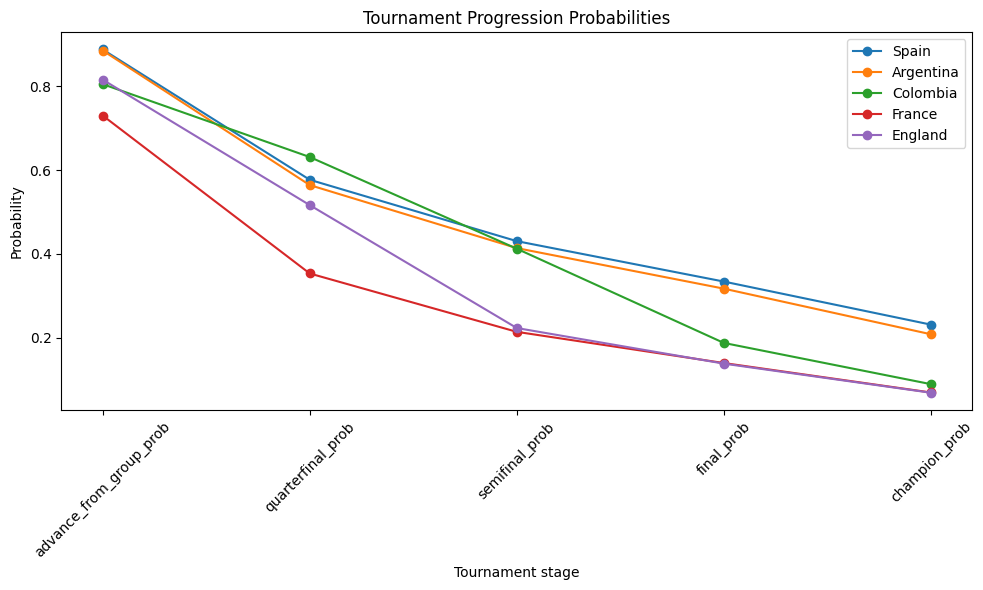

In [3]:
stage_cols = [
    c for c in [
        "advance_from_group_prob",
        "quarterfinal_prob",
        "semifinal_prob",
        "final_prob",
        "champion_prob",
    ]
    if c in team_probabilities.columns
]

top_5_progression = (
    team_probabilities
    .sort_values("champion_prob", ascending=False)
    .head(5)
    .set_index("team")[stage_cols]
)

plt.figure(figsize=(10, 6))

for team in top_5_progression.index:
    plt.plot(
        top_5_progression.columns,
        top_5_progression.loc[team],
        marker="o",
        label=team,
    )

plt.title("Tournament Progression Probabilities")
plt.xlabel("Tournament stage")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

output_dir = PROJECT_ROOT / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "team_progression.png", dpi=300)

plt.show()

## 1. Forecasting objective

The objective of the project is to estimate **tournament-level probabilities** for the FIFA World Cup 2026.

Rather than producing a single bracket prediction, the system estimates:

- the probability that each team advances from the group stage
- the probability of reaching each knockout round
- the probability of winning the tournament

This is a better representation of football forecasting because knockout tournaments are inherently stochastic.


## 2. Methodology at a glance

The forecasting workflow combines two layers:

### Match prediction layer
A probabilistic match model estimates:

- `P(win)`
- `P(draw)`
- `P(loss)`

from the perspective of Team A using historical match data and engineered team-strength features.

### Tournament simulation layer
Those match probabilities are used inside a **Monte Carlo tournament simulator**:

```text
predict_match(team_a, team_b)
↓
sample match outcome
↓
update tournament state
↓
simulate full tournament
↓
repeat thousands of times
```

The result is a probability distribution over tournament outcomes rather than a single deterministic bracket.


## 3. Load forecast artifacts

The notebook reads the simulation outputs generated by the reporting layer.

Expected files:

- `team_probabilities.csv`
- `champion_distribution.csv`
- `summary_metadata.json` (optional)
- `match_logs.parquet` (optional)


In [4]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
SIM_OUTPUT_PATH = PROJECT_ROOT / "data" / "outputs" / "simulation"

team_prob_path = SIM_OUTPUT_PATH / "team_probabilities.csv"
champion_dist_path = SIM_OUTPUT_PATH / "champion_distribution.csv"
summary_metadata_path = SIM_OUTPUT_PATH / "summary_metadata.json"
match_logs_path = SIM_OUTPUT_PATH / "match_logs.parquet"

print("Simulation output directory:", SIM_OUTPUT_PATH)
print("team_probabilities exists:", team_prob_path.exists())
print("champion_distribution exists:", champion_dist_path.exists())
print("summary_metadata exists:", summary_metadata_path.exists())
print("match_logs exists:", match_logs_path.exists())

Simulation output directory: C:\Users\manue\Projects\world-cup-2026-forecast\data\outputs\simulation
team_probabilities exists: True
champion_distribution exists: True
summary_metadata exists: True
match_logs exists: True


In [5]:
import json

team_probabilities = pd.read_csv(team_prob_path)
champion_distribution = pd.read_csv(champion_dist_path)

summary_metadata = None
if summary_metadata_path.exists():
    with open(summary_metadata_path, "r", encoding="utf-8") as f:
        summary_metadata = json.load(f)

match_logs_df = None
if match_logs_path.exists():
    match_logs_df = pd.read_parquet(match_logs_path)

print("team_probabilities shape:", team_probabilities.shape)
print("champion_distribution shape:", champion_distribution.shape)
if summary_metadata is not None:
    print("summary_metadata keys:", list(summary_metadata.keys()))
if match_logs_df is not None:
    print("match_logs shape:", match_logs_df.shape)

team_probabilities shape: (32, 9)
champion_distribution shape: (32, 3)
summary_metadata keys: ['tournament_name', 'tournament_id', 'model_name', 'neutral_venue', 'knockout_draw_resolution', 'num_groups', 'group_size', 'teams_advancing_per_group', 'num_simulations', 'num_teams']
match_logs shape: (6300000, 12)


## 4. Simulation configuration

This table provides context on the forecast generation setup.


In [6]:
if summary_metadata is not None:
    pd.DataFrame([summary_metadata])
else:
    print("summary_metadata.json not available.")

## 5. Main championship forecast

We first rank teams by **championship probability**. This is the most direct summary of the forecast.


In [7]:
champion_dist_sorted = champion_distribution.sort_values("champion_prob", ascending=False).reset_index(drop=True)
champion_dist_sorted.head(15)

,team,titles,champion_prob
0,Spain,23125,0.2312
1,Argentina,20819,0.2082
2,Colombia,8909,0.0891
3,France,6922,0.0692
4,England,6865,0.0686
5,Portugal,4850,0.0485
6,Brazil,4654,0.0465
7,Netherlands,4646,0.0465
8,Senegal,3520,0.0352
9,Ecuador,2806,0.0281


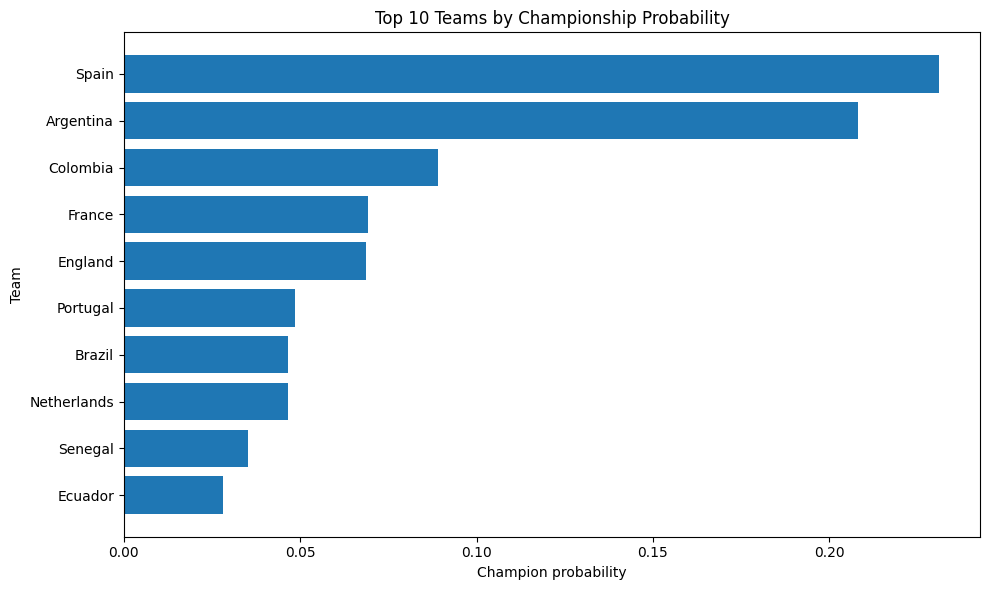

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

top_10_champion = champion_dist_sorted.head(10).copy()

plt.figure(figsize=(10,6))
plt.barh(top_10_champion["team"], top_10_champion["champion_prob"])

plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Top 10 Teams by Championship Probability")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Championship contenders

The simulation identifies a clear pair of leading title contenders.

Spain emerges as the most likely champion with a title probability of **23.1%**, closely followed by Argentina at **20.8%**. These two teams form the top tier of the forecast and together account for a substantial portion of the overall championship probability mass.

A second tier of contenders follows at a considerable distance. Colombia appears as the strongest challenger among this group with an **8.9%** championship probability. France (**6.9%**) and England (**6.9%**) also maintain meaningful chances of winning the tournament.

Beyond these teams, several nations remain competitive but with significantly lower probabilities. Portugal, Brazil, and the Netherlands each hold championship probabilities around **4–5%**, indicating that they could plausibly win the tournament under favorable bracket paths and match outcomes.

Overall, the forecast suggests a tournament with **two primary favorites**, a small group of secondary contenders, and a long tail of teams requiring multiple upsets to lift the trophy.


## 6. Team progression profile

Championship probability alone can hide important structural differences.

A team may have:

- a strong chance to advance from the group stage
- a decent chance to reach quarterfinals
- but a much lower probability of winning the title

Progression probabilities reveal where teams are most likely to drop out.


In [9]:
team_prob_sorted = team_probabilities.sort_values("champion_prob", ascending=False).reset_index(drop=True)
team_prob_sorted.head(20)

,team,group_stage_exit_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,advance_from_group_prob,non_champion_prob
0,Spain,0.1120,0.8880,0.5770,0.4305,0.3340,0.2312,0.8880,0.7688
1,Argentina,0.1145,0.8855,0.5643,0.4139,0.3171,0.2082,0.8855,0.7918
2,Colombia,0.1947,0.8053,0.6313,0.4124,0.1875,0.0891,0.8053,0.9109
3,France,0.2698,0.7302,0.3533,0.2140,0.1395,0.0692,0.7303,0.9308
4,England,0.1840,0.8160,0.5165,0.2231,0.1381,0.0686,0.8160,0.9314
5,Portugal,0.2322,0.7678,0.4417,0.1770,0.1062,0.0485,0.7678,0.9515
6,Brazil,0.3305,0.6695,0.2882,0.1644,0.1013,0.0465,0.6695,0.9535
7,Netherlands,0.2374,0.7626,0.4909,0.2838,0.1109,0.0465,0.7626,0.9535
8,Senegal,0.2844,0.7156,0.4425,0.2427,0.0896,0.0352,0.7156,0.9648
9,Ecuador,0.3728,0.6272,0.4264,0.2254,0.0762,0.0281,0.6272,0.9719


In [10]:
stage_cols = [
    c for c in [
        "advance_from_group_prob",
        "round_of_16_prob",
        "quarterfinal_prob",
        "semifinal_prob",
        "final_prob",
        "champion_prob",
    ]
    if c in team_prob_sorted.columns
]

progression_table = team_prob_sorted[["team"] + stage_cols].head(12).copy()
progression_table

,team,advance_from_group_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob
0,Spain,0.8880,0.8880,0.5770,0.4305,0.3340,0.2312
1,Argentina,0.8855,0.8855,0.5643,0.4139,0.3171,0.2082
2,Colombia,0.8053,0.8053,0.6313,0.4124,0.1875,0.0891
3,France,0.7303,0.7302,0.3533,0.2140,0.1395,0.0692
4,England,0.8160,0.8160,0.5165,0.2231,0.1381,0.0686
5,Portugal,0.7678,0.7678,0.4417,0.1770,0.1062,0.0485
6,Brazil,0.6695,0.6695,0.2882,0.1644,0.1013,0.0465
7,Netherlands,0.7626,0.7626,0.4909,0.2838,0.1109,0.0465
8,Senegal,0.7156,0.7156,0.4425,0.2427,0.0896,0.0352
9,Ecuador,0.6272,0.6272,0.4264,0.2254,0.0762,0.0281


In [11]:
top_8_teams = team_prob_sorted["team"].head(8).tolist()

plot_df = (
    team_prob_sorted[team_prob_sorted["team"].isin(top_8_teams)][["team"] + stage_cols]
    .set_index("team")
    .T
)

plot_df

team,Spain,Argentina,Colombia,France,England,Portugal,Brazil,Netherlands
advance_from_group_prob,0.8880,0.8855,0.8053,0.7303,0.8160,0.7678,0.6695,0.7626
round_of_16_prob,0.8880,0.8855,0.8053,0.7302,0.8160,0.7678,0.6695,0.7626
quarterfinal_prob,0.5770,0.5643,0.6313,0.3533,0.5165,0.4417,0.2882,0.4909
semifinal_prob,0.4305,0.4139,0.4124,0.2140,0.2231,0.1770,0.1644,0.2838
final_prob,0.3340,0.3171,0.1875,0.1395,0.1381,0.1062,0.1013,0.1109
champion_prob,0.2312,0.2082,0.0891,0.0692,0.0686,0.0485,0.0465,0.0465


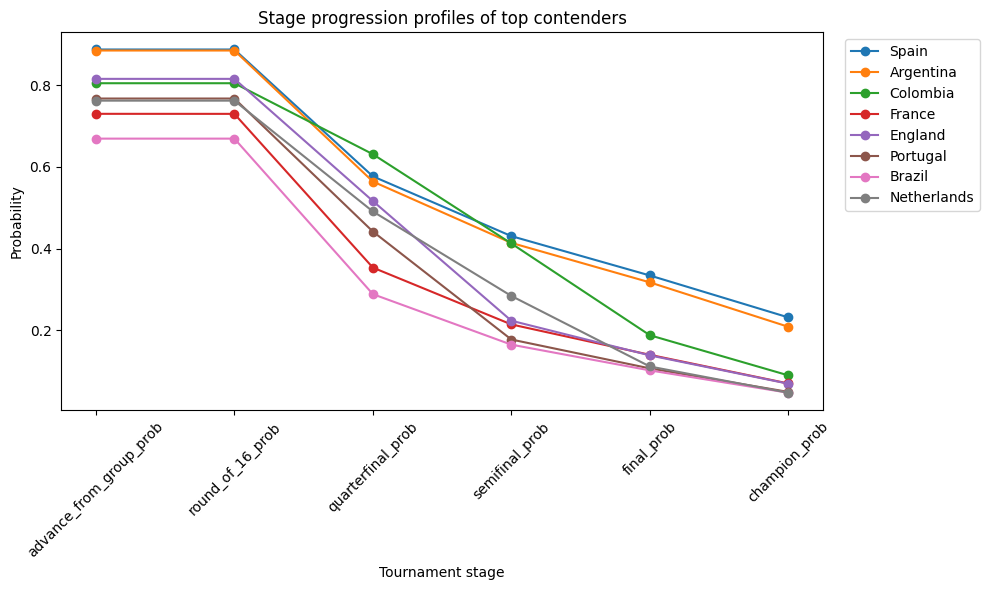

In [12]:
plt.figure(figsize=(10, 6))

for team in plot_df.columns:
    plt.plot(plot_df.index, plot_df[team], marker="o", label=team)

plt.title("Stage progression profiles of top contenders")
plt.xlabel("Tournament stage")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Progression profiles

Examining the progression probabilities across tournament stages provides further insight into the structure of the forecast.

Spain and Argentina demonstrate remarkably consistent strength throughout the tournament. Both teams advance from the group stage in nearly **89% of simulations** and maintain high probabilities of reaching the later rounds.

Spain in particular shows strong persistence across stages:

- Quarterfinals: **57.7%**
- Semifinals: **43.0%**
- Final: **33.4%**
- Champion: **23.1%**

Argentina displays a very similar profile, indicating that both teams are expected to perform consistently well regardless of the specific knockout bracket path.

Colombia represents an interesting case. While its championship probability (**8.9%**) is significantly lower than the top two teams, its probability of reaching the quarterfinals (**63.1%**) is actually the highest among all teams. This suggests a team with strong early-round performance but somewhat lower likelihood of converting deep tournament runs into titles.

Teams such as France and England show solid advancement probabilities but a sharper decline in later rounds, indicating that they remain competitive but face stronger resistance in the final stages of the tournament.


## 7. Favorites, second tier, and dark horses

A useful portfolio-level framing is to bucket teams into narrative tiers.


In [13]:
forecast_story_df = team_prob_sorted[[
    "team",
    "champion_prob",
    *[c for c in ["semifinal_prob", "final_prob", "advance_from_group_prob"] if c in team_prob_sorted.columns]
]].copy()

forecast_story_df["tier"] = np.select(
    [
        forecast_story_df["champion_prob"] >= 0.15,
        forecast_story_df["champion_prob"] >= 0.05,
        forecast_story_df["champion_prob"] >= 0.01,
    ],
    [
        "Top favorite",
        "Strong contender",
        "Dark horse",
    ],
    default="Long shot",
)

forecast_story_df.head(20)

,team,champion_prob,semifinal_prob,final_prob,advance_from_group_prob,tier
0,Spain,0.2312,0.4305,0.3340,0.8880,Top favorite
1,Argentina,0.2082,0.4139,0.3171,0.8855,Top favorite
2,Colombia,0.0891,0.4124,0.1875,0.8053,Strong contender
3,France,0.0692,0.2140,0.1395,0.7303,Strong contender
4,England,0.0686,0.2231,0.1381,0.8160,Strong contender
5,Portugal,0.0485,0.1770,0.1062,0.7678,Dark horse
6,Brazil,0.0465,0.1644,0.1013,0.6695,Dark horse
7,Netherlands,0.0465,0.2838,0.1109,0.7626,Dark horse
8,Senegal,0.0352,0.2427,0.0896,0.7156,Dark horse
9,Ecuador,0.0281,0.2254,0.0762,0.6272,Dark horse


In [14]:
forecast_story_df["tier"].value_counts().rename_axis("tier").reset_index(name="num_teams")

,tier,num_teams
0,Long shot,17
1,Dark horse,10
2,Strong contender,3
3,Top favorite,2


In [15]:
forecast_story_df["tier"].value_counts()

tier
Long shot           17
Dark horse          10
Strong contender     3
Top favorite         2
Name: count, dtype: int64

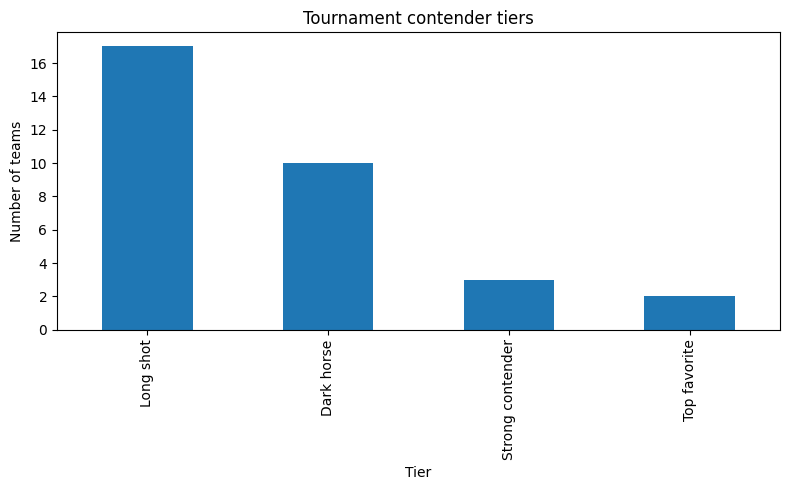

In [16]:
import matplotlib.pyplot as plt

tier_counts = forecast_story_df["tier"].value_counts()

plt.figure(figsize=(8,5))
tier_counts.plot(kind="bar")

plt.title("Tournament contender tiers")
plt.ylabel("Number of teams")
plt.xlabel("Tier")

plt.tight_layout()
plt.show()

### Contender tiers

Based on championship probabilities, teams can be grouped into several forecasting tiers:

- **Top favorites (2 teams)**  
  Spain, Argentina

- **Strong contenders (3 teams)**  
  Colombia, France, England

- **Dark horses (10 teams)**  
  Portugal, Brazil, Netherlands, Senegal, Ecuador, Uruguay, Italy, Croatia, Germany, Switzerland

- **Long shots (17 teams)**  
  Remaining teams with championship probabilities below roughly 1%.

The distribution of teams across tiers highlights the asymmetric structure of the forecast. While only two teams exceed a 20% championship probability, a large group of teams remains capable of reaching advanced tournament stages.

This structure is typical for international tournaments, where a small number of elite teams dominate title probabilities while a broader set of competitive teams can still produce deep runs.


## 8. Forecast concentration and uncertainty

A forecast is not just about ranking teams. It is also about understanding **how concentrated** the probability mass is.

We compute:

- top-5 championship probability mass
- top-10 championship probability mass
- entropy of the champion distribution


In [17]:
top_5_mass = champion_dist_sorted["champion_prob"].head(5).sum()
top_10_mass = champion_dist_sorted["champion_prob"].head(10).sum()

entropy = -(champion_dist_sorted["champion_prob"] * np.log(
    np.clip(champion_dist_sorted["champion_prob"], 1e-12, 1)
)).sum()

uncertainty_summary = pd.DataFrame([{
    "top_5_champion_probability_mass": top_5_mass,
    "top_10_champion_probability_mass": top_10_mass,
    "champion_distribution_entropy": entropy,
}]).round(4)

uncertainty_summary

,top_5_champion_probability_mass,top_10_champion_probability_mass,champion_distribution_entropy
0,0.6663,0.8711,2.4771


### Forecast concentration

The championship probability distribution reveals a moderately concentrated forecast.

The top five teams account for approximately **66.6%** of total championship probability mass, while the top ten teams collectively represent about **87.1%** of the distribution.

This indicates that although a relatively small group of teams dominates the forecast, the model still assigns meaningful probability to a broader set of contenders.

The entropy of the champion distribution is **2.48**, suggesting a tournament outcome that remains meaningfully uncertain despite the presence of strong favorites.


## 9. Optional match-log diagnostics

If match-level logs are available, they can be used for QA and realism checks.

Examples:

- stage distribution of simulated matches
- winner frequencies
- upset-rate analysis
- knockout-round behavior

If the required probability columns are not available in the logs, upset analysis may not be possible yet.


In [18]:
if match_logs_df is not None:
    print("Available match log columns:")
    print(sorted(match_logs_df.columns))
else:
    print("match_logs.parquet not available.")

Available match log columns:
['decided_by', 'draw_prob', 'outcome', 'simulation_id', 'stage', 'team_a', 'team_a_goals', 'team_a_loss_prob', 'team_a_win_prob', 'team_b', 'team_b_goals', 'winner']


In [19]:
if match_logs_df is not None and "stage" in match_logs_df.columns:
    match_logs_df["stage"].value_counts().rename_axis("stage").reset_index(name="matches")
else:
    print("Stage-level match diagnostics not available.")

### Interpreting uncertainty in tournament forecasts

It is important to note that even the strongest teams rarely exceed championship probabilities above 25% in tournament forecasting models.

This reflects the inherent randomness of knockout competitions. A single unfavorable matchup, an early red card, or a penalty shootout can dramatically alter the outcome of the tournament.

Therefore, a team with a 20–25% championship probability should be interpreted not as a guaranteed winner, but as the most likely outcome among many plausible scenarios.

The simulation framework captures this uncertainty by repeatedly sampling match outcomes and tournament paths, producing a distribution of possible tournament results rather than a single deterministic prediction.

## 10. Executive summary

At the highest level, this forecasting system produces three types of insight:

1. **Who the favorites are**  
   Championship probabilities reveal the strongest title contenders.

2. **How far teams are likely to go**  
   Stage-level probabilities distinguish deep contenders from early-round specialists.

3. **How uncertain the tournament remains**  
   Concentration metrics and entropy quantify whether the title race is narrow or open.

This is more informative than a single bracket prediction because it respects the uncertainty inherent in football tournaments.


## 11. Limitations

This forecast should be interpreted with several constraints in mind:

- It is driven by a match-outcome model rather than a full goal-scoring model.
- It does not yet incorporate player availability, injuries, or final squad selection.
- Tournament configuration may still evolve if final qualified teams or official groups are not yet fixed.
- Forecast quality ultimately depends on the calibration and realism of the underlying match probabilities.

These limitations are normal for a baseline probabilistic forecasting system and point directly to the next development steps.


## 12. Conclusions

Using a Monte Carlo simulation framework and a probabilistic match prediction model, this analysis estimates the likelihood of each team advancing through the stages of the FIFA World Cup 2026.

The results highlight **Spain and Argentina as the two leading title contenders**, each with championship probabilities above 20%. A second group of strong challengers — including Colombia, France, and England — retains meaningful chances of winning the tournament, while a broader set of teams remains capable of producing deep runs.

Despite the presence of favorites, the forecast remains far from deterministic. The top five teams account for roughly two thirds of the championship probability mass, leaving substantial room for unexpected outcomes.

This uncertainty is a defining characteristic of international knockout tournaments and underscores the value of probabilistic forecasting approaches. Rather than predicting a single outcome, the simulation framework provides a full distribution of possible tournament scenarios, offering a more realistic representation of competitive uncertainty.

Future work could extend this framework through improved match-level models, richer feature engineering, and calibration analyses linking match predictions to tournament-level forecasting performance.


## 13. Next storytelling extensions

Useful additions for future portfolio iterations:

- annotate the forecast with team-level tactical context
- add bracket-path visuals for top contenders
- compare multiple model versions side by side
- include dashboard screenshots and exported forecast tables
- add a scenario section for injuries, updated Elo, or alternative tournament paths
